In [44]:
%cd /Users/arikreuter/Documents/PhD/CausalPriorFitting/src

/Users/arikreuter/Documents/PhD/CausalPriorFitting/src


In [45]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:
from priors.causal_prior.causal_graph.GraphSampler import GraphSampler
from priors.causal_prior.mechanisms.SampleMLPMechanism import SampleMLPMechanism
from priors.causal_prior.noise_distributions.MixedDist import MixedDist
from priors.causal_prior.scm.SCM import SCM
from priors.causal_prior.causal_graph.CausalDAG import CausalDAG
from priors.causal_prior.mechanisms.BaseMechanism import BaseMechanism
from priors.causal_prior.mechanisms.IgnoreParentsMechanism import IgnoreParentsMechanism
from priors.causal_prior.noise_distributions.DistributionInterface import Distribution
from priors.causal_prior.noise_distributions.ResamplingDist import ResamplingDist
import torch

In [47]:
NUM_NODES = 3
p = 0.5 
SEED = 43
NOISE_STD = 0.1
BATCH_SIZE = 5

# graph
graph_sampler = GraphSampler(seed=SEED)
graph = graph_sampler.sample_dag(
   num_nodes=NUM_NODES,
    p=p,
)

new_edges = [(1, 2), 
             (1, 0), 
             (0, 2)]
graph.clear_edges()
graph.add_edges_from(new_edges)



causal_dag = CausalDAG(
    g=graph,
    check_acyclic=True
)

# mechanisms 
mechanisms = {}
for node in causal_dag.nodes():
    # assign mechanisms
    mechanisms[node] = SampleMLPMechanism(
        input_dim=len(causal_dag.parents(node)),
        node_shape=(1,),  # scalar output

    )

# noise distributions

exogenous_variables = causal_dag.exogenous_variables()
endogenous_variables = causal_dag.endogenous_variables()

exo_noise = {}
for var in exogenous_variables:
    exo_noise[var] = MixedDist(
        std = NOISE_STD
    )

endo_noise = {}
for var in endogenous_variables:
    endo_noise[var] = MixedDist(
        std = NOISE_STD
    )



In [48]:
scm = SCM(
    dag = causal_dag,
    mechanisms = mechanisms,
    exogenous_noise = exo_noise,
    endogenous_noise = endo_noise,
)



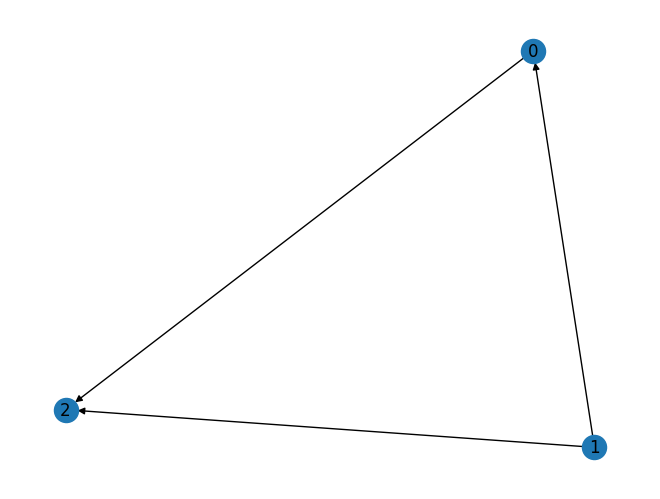

In [49]:
scm.dag.draw()

In [50]:
intervention_node = 0

In [51]:
#observational_sampling

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs0 = scm.propagate(num_samples=BATCH_SIZE)

In [ ]:
# for interventional sampling, first determine intervention node

scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

obs1 = scm.propagate(num_samples=BATCH_SIZE) #sample observational data again. 

intervention_samples = obs1[intervention_node] # collect set of observational samples for the intervention node

interventional_dist = ResamplingDist(intervention_samples) # create resampling distribution based on observational samples for the intervention node


scm.set_mechanism(
    node=intervention_node,
    mechanism=IgnoreParentsMechanism(), 
)

if intervention_node in scm.dag.endogenous_variables():
    scm.endogenous_noise[intervention_node] = interventional_dist

if intervention_node in scm.dag.exogenous_variables():
    scm.exogenous_noise[intervention_node] = interventional_dist


scm.sample_exogenous(num_samples=BATCH_SIZE)
scm.sample_endogenous(num_samples=BATCH_SIZE)

interv1 = scm.propagate(num_samples=BATCH_SIZE)


TypeError: SCM.set_mechanism() got an unexpected keyword argument 'validate'

In [ ]:
intervention_samples

tensor([[ 0.0152],
        [-0.0707],
        [ 0.2792],
        [ 0.1716],
        [-0.0148]])

In [ ]:
interv1[intervention_node]

tensor([ 0.1716, -0.0707,  0.2792, -0.0148,  0.0152])